In [ ]:
### 1. Load And Merge

In [ ]:
import pandas as pd
import glob


In [ ]:
import pandas as pd
import glob

# Load all CSV files
files = glob.glob("/content/PRSA_Data_*.csv")

df_list = []

for file in files:
    df = pd.read_csv(file)
    df['station'] = file.split('_')[2]  # extract station name
    df_list.append(df)

# Merge all
data = pd.concat(df_list, ignore_index=True)

# Create datetime column
data['datetime'] = pd.to_datetime(data[['year','month','day','hour']])

data.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,9.0,9.0,6.0,17.0,200.0,62.0,0.3,1021.9,-19.0,0.0,WNW,2.0,Wanshouxigong,2013-03-01 00:00:00
1,2,2013,3,1,1,11.0,11.0,7.0,14.0,200.0,66.0,-0.1,1022.4,-19.3,0.0,WNW,4.4,Wanshouxigong,2013-03-01 01:00:00
2,3,2013,3,1,2,8.0,8.0,NaN,16.0,200.0,59.0,-0.6,1022.6,-19.7,0.0,WNW,4.7,Wanshouxigong,2013-03-01 02:00:00
3,4,2013,3,1,3,8.0,8.0,3.0,16.0,NaN,NaN,-0.7,1023.5,-20.9,0.0,NW,2.6,Wanshouxigong,2013-03-01 03:00:00
4,5,2013,3,1,4,8.0,8.0,3.0,NaN,300.0,36.0,-0.9,1024.1,-21.7,0.0,WNW,2.5,Wanshouxigong,2013-03-01 04:00:00


In [ ]:
### 2. EDA (Exploratory Data Analysis)

In [ ]:
print(data.shape)
print(data.info())
print(data.describe())

(140256, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140256 entries, 0 to 140255
Data columns (total 19 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   No        140256 non-null  int64         
 1   year      140256 non-null  int64         
 2   month     140256 non-null  int64         
 3   day       140256 non-null  int64         
 4   hour      140256 non-null  int64         
 5   PM2.5     137156 non-null  float64       
 6   PM10      137816 non-null  float64       
 7   SO2       136861 non-null  float64       
 8   NO2       136452 non-null  float64       
 9   CO        134890 non-null  float64       
 10  O3        136580 non-null  float64       
 11  TEMP      140113 non-null  float64       
 12  PRES      140114 non-null  float64       
 13  DEWP      140111 non-null  float64       
 14  RAIN      140111 non-null  float64       
 15  wd        139657 non-null  object        
 16  WSPM      140137 non-null

In [ ]:
data.isnull().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,3100
PM10,2440
SO2,3395
NO2,3804
CO,5366


In [ ]:
# Fill using forward fill (time series)
data = data.sort_values(by='datetime')
data.fillna(method='ffill', inplace=True)

/tmp/ipykernel_8137/959336293.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)


In [ ]:
#drop duplicates
data.drop_duplicates(inplace=True)

In [ ]:
# Extract time features
data['year'] = data['datetime'].dt.year
data['month'] = data['datetime'].dt.month
data['day'] = data['datetime'].dt.day
data['hour'] = data['datetime'].dt.hour

# AQI Category (simple logic)
def categorize_pm25(x):
    if x <= 50:
        return 'Good'
    elif x <= 100:
        return 'Moderate'
    elif x <= 150:
        return 'Unhealthy'
    else:
        return 'Hazardous'

data['AQI_Level'] = data['PM2.5'].apply(categorize_pm25)

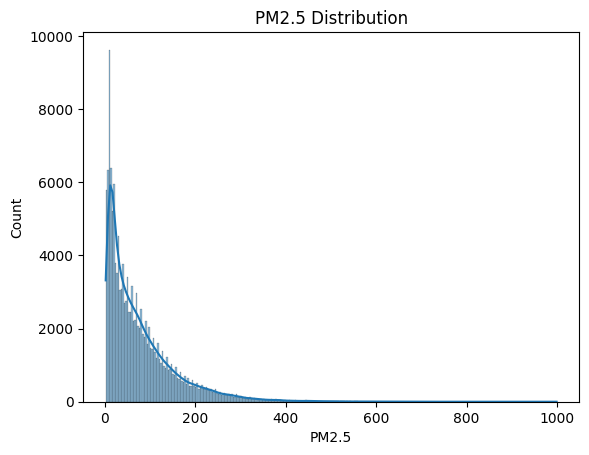

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data['PM2.5'], kde=True)
plt.title("PM2.5 Distribution")
plt.show()

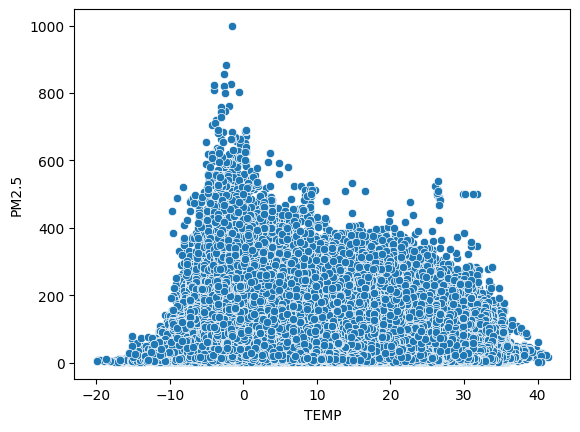

In [ ]:
sns.scatterplot(x='TEMP', y='PM2.5', data=data)
plt.show()


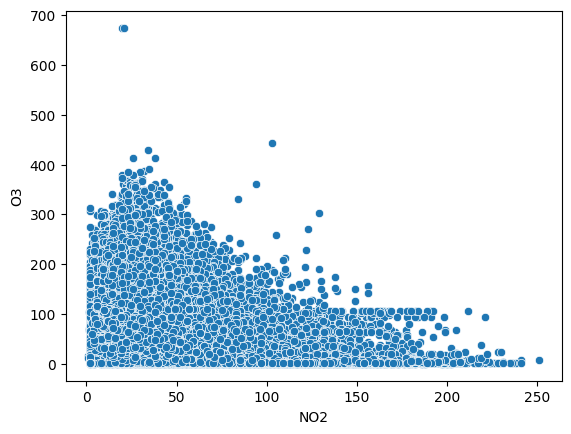

In [ ]:
sns.scatterplot(x='NO2', y='O3', data=data)
plt.show()

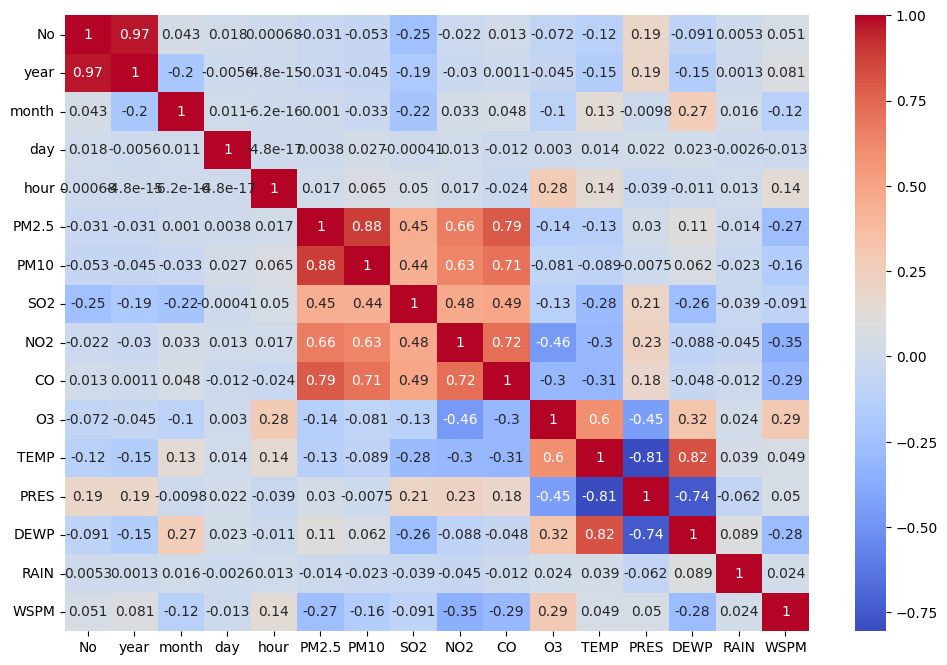

<Figure size 640x480 with 0 Axes>

In [ ]:
corr = data.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()
plt.tight_layout()

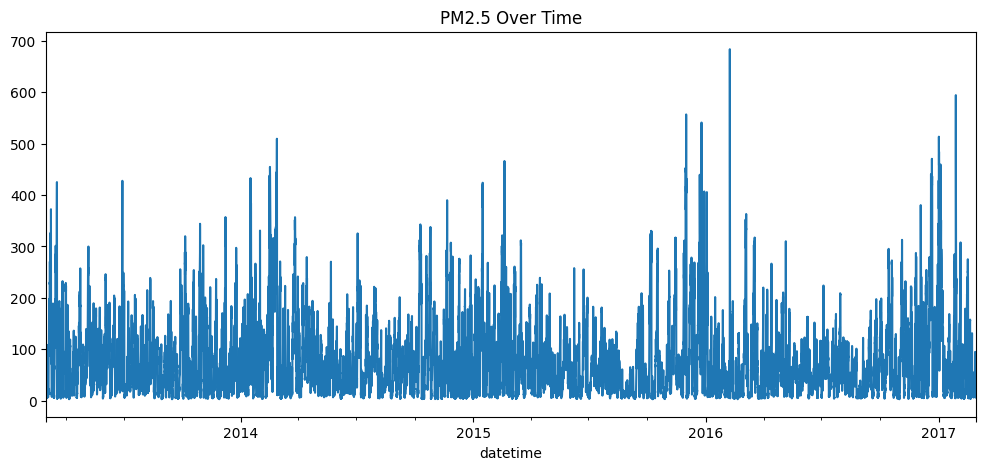

In [ ]:
data.groupby('datetime')['PM2.5'].mean().plot(figsize=(12,5))
plt.title("PM2.5 Over Time")
plt.show()

In [ ]:
features = ['PM10','SO2','NO2','CO','O3','TEMP','PRES','DEWP','RAIN','WSPM']
X = data[features]
y = data['PM2.5']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)

RandomForestRegressor()

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
pred_lr = lr.predict(X_test)
print("LR R2:", r2_score(y_test, pred_lr))

LR R2: 0.842397489217092


In [ ]:
pred_rf=rf.predict(X_test)
print("RF R2:", r2_score(y_test, pred_rf))

RF R2: 0.9284421408381088


In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
params = {'n_estimators':[50,100], 'max_depth':[5,10]}
grid = GridSearchCV(RandomForestRegressor(), params, cv=3)

In [ ]:
grid.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestRegressor(),
             param_grid={'max_depth': [5, 10], 'n_estimators': [50, 100]})

In [ ]:
best_model = grid.best_estimator_

In [ ]:
import pickle

In [ ]:
with open('model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

In [ ]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 51.4 MB/s eta 0:00:00


In [ ]:
data.to_csv('data.csv', index=False)

In [ ]:
!(streamlit run /content/app.py)




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.12.236.159:8501

  Stopping...


In [ ]:
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [ ]:
#optimise model peformance